# Effective connectivity in the NETSIM dataset

In [2]:
import matplotlib.pylab as plt
import numpy as np
import networkx as nx

### Loading the results from the estimation procedure for the NETSIM dataset

Recall that our experiments also included several lengths of the original time series. All these results are grouped into a separate folder inside a big directory for every simulation.
The relevant directories as defined below and can be easily retrieved as follows:

In [3]:
# simulations = [1, 7, 15, 19, 28]
# lengths = [70, 75, 80, 85, 90, 95, 100]
main_dir = lambda sim: f"Results_Netsim-Dataset_Sim-{sim}"
length_dir = lambda length, sim: f"/Results_Dataset-Netsim_Sim-{sim}_Length-{length}"
results_dir = lambda length, sim: f"Results_Netsim-Dataset_Sim-{sim}/Results_Dataset-Netsim_Sim-{sim}_Length-{length}"

We import the relevant methods from the submodules in the code. For the specific case of Netsim, we provide a convenient wrapper class that contains the necessary utilities. All of these utilities however can be found independently in the code and used for your own dataset.

In [4]:
from analysis.ground_truths.netsim import Netsim

# Specfics of your results
simulation_number = 7
length_number = 100
ROI_Labels = None
results = results_dir(length_number,simulation_number)

# Instantiate the class containing all of the necessary utilities
netsim_results = Netsim(
    results,
    simulation=simulation_number,
    ROI_Labels=ROI_Labels
)

In [5]:
# Number of subjects in the dataset
N_subjects = len(netsim_results.subject_list)

# Lets specify the weighted and binary ground truths
w_ground_truths, b_ground_truth = netsim_results.weighted_gts, netsim_results.binary_gt

# Load the reconstructed networks for each subject
binary_networks = netsim_results.get_networks_Adjacency(weighted=False, bidirectional=False, save_in=False)
weighted_networks = netsim_results.get_networks_Adjacency(weighted=True, bidirectional=False, save_in=False)

The adjacency matrices are stored in a dictionary permiting easy access to individual data points:

Ground truth:
[[0. 1. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]]
Reconstructed binary network for the example subject
[[0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]]
Reconstructed weighted network for the example subject
[[0.00000000e+00 9.99999981e-01 4.73994343e-05 9.99803092e-01
  2.76840784e-03]
 [1.86776392e-08 0.00000000e+00 9.96329325e-01 7.81804649e-01
  7.29253005e-03]
 [9.99952601e-01 3.67067480e-03 0.00000000e+00 1.00000000e+00
  1.00000000e+00]
 [1.94563144e-04 2.18195351e-01 0.00000000e+00 0.00000000e+00
  1.23476394e-01]
 [9.97231592e-01 9.92707470e-01 1.15323306e-11 8.76523606e-01
  0.00000000e+00]]
Simple visualization


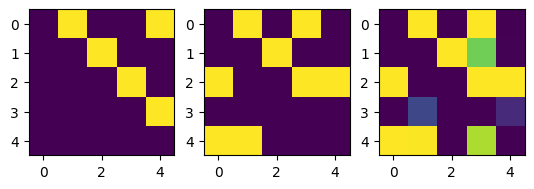

In [6]:
# We can access a particular time lag and subject if we wish to
example_lag = -1
example_lag_ID = 29
subject_number = 50
example_subject = f"sub-{subject_number}_sim-{simulation_number}_Length-{length_number}_Method-RCC"

example_subject_ID = netsim_results.subjects[example_subject]
example_network_b = binary_networks[example_lag][example_subject_ID]
example_network_w = weighted_networks[example_lag][example_subject_ID]

print("Ground truth:")
print(b_ground_truth)
print("Reconstructed binary network for the example subject")
print(example_network_b)
print("Reconstructed weighted network for the example subject")
print(example_network_w)
print("Simple visualization")
fig, ax = plt.subplots(1,3)
ax[0].imshow(b_ground_truth)
ax[1].imshow(example_network_b)
ax[2].imshow(example_network_w)

Another important feature is the computation of the consistency across binary reconstructions. This simple yet easily interpretable metric gathers the connections that are most consistent - up to a predefined threshold - across the whole dataset. Following the idea of wrapping everything into the NEtsim object, we can compute these maps in a similar manner as everything we have already done. However, this method is present and usable from another class.

[[ nan 0.72  nan  nan  nan]
 [ nan  nan 0.76 0.72  nan]
 [ nan  nan  nan 0.7   nan]
 [ nan  nan  nan  nan 0.62]
 [ nan  nan  nan  nan  nan]]


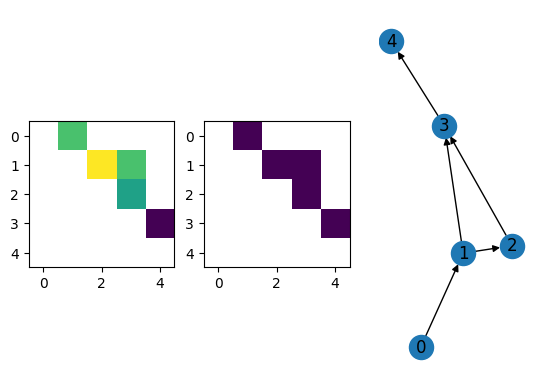

In [7]:
graph, adjacency = netsim_results.group_consistency(lag=example_lag, threshold=0.6)
_, binary_adjacency = netsim_results.group_consistency(lag=example_lag, threshold=0.6, make_binary=True)
print(adjacency)

fig, ax = plt.subplots(1,3)
ax[0].imshow(adjacency)
ax[1].imshow(binary_adjacency)
nx.draw(graph, ax=ax[2], pos=nx.spring_layout(graph), with_labels=True)


One of the advantages of this method is that we can explore the interactions at multiple lags with a straighforward interpretation: delayed interactions. 

This functionality is readily usable in the toolbox by just calling the "plot_interaction_ij". This will plot the predictablity scores together with the statistical evidence computed at the dataset level

Loading interaction scores from all subjects ...


100%|██████████| 50/50 [00:00<00:00, 71.89it/s]


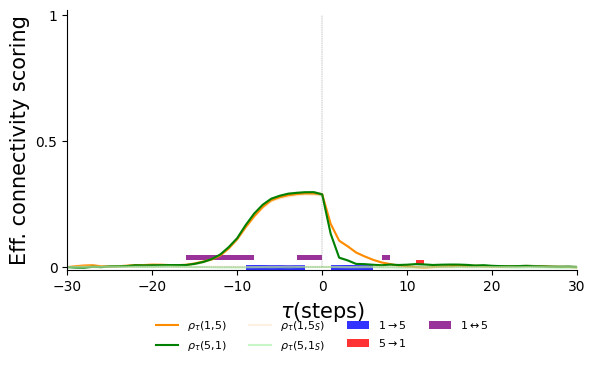

In [8]:
netsim_results.plot_interaction_ij(1,5)

Loading interaction scores from all subjects ...


100%|██████████| 50/50 [00:00<00:00, 70.69it/s]


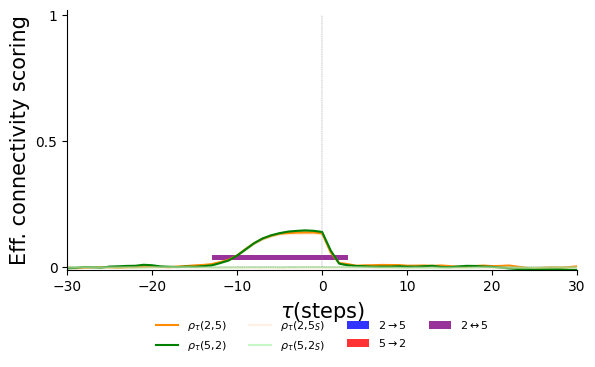

In [9]:
netsim_results.plot_interaction_ij(2,5)

Loading interaction scores from all subjects ...


100%|██████████| 50/50 [00:00<00:00, 72.05it/s]


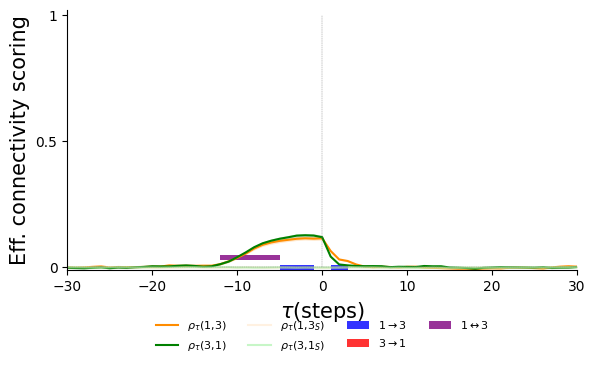

In [10]:
netsim_results.plot_interaction_ij(1,3)

### Accuracies of the reconstructions

This part of the analysis is restricted to cases where a known ground-truth is available. Alternatively, one might consider any system with a known physical structure to be a proxy for such ground truth. For the NETSIM dataset, clear ground truths can be loaded and exactly compared against our results.

To study the goodness of the reconstructions we constrain the networks to the k-th neighbor interactions. For that, we employ the methods found in the analysis.utils.Constraints class (already available within the Netsim wrapper). The motivation for this is to be able to study first, second, ... interactions within a system with a known physical structure. 

Moreover, we wish to be able to disentangle typical network motifs present in complex systems (e.g., common cause, indirect causation).

In [11]:
import numpy as np

# Let's constrain the results to the 1st neighbor interactions based on the known structure
k_neighbor = 1
predictions_b_k, gts_k = netsim_results.constrain_datset(binary_networks)
predictions_w_k, _ = netsim_results.constrain_datset(weighted_networks)

# The real network remains unaltered through time, but this is not necessarily true for every system. 
gts_k = gts_k[-1]
all_gts_k = np.tile(gts_k, N_subjects) # ground truths: [gt, gt, gt, ...]

# Lags present in the dataset
all_lags = list(predictions_b_k.keys())
N_lags = len(all_lags)

We now have all the data loaded into a compact python object. There is still a lot of data however to go through. One of the advantages is that the predictions are stored in an iterable object and that the temporal lag is uniquely identified by its value. Then, each lag can be studied independently.

The next step is to load and compute the metrics that we are going to evaluate. Appropriate statistical procedures are also readily available: Bootstrapping, ROC analyses, DET analyses and DeLong. Examples are shown below in this tutorial.

In [12]:
from analysis.ground_truths.utils import Metrics

# Option 1: We consider the results of each subject as a sample allowing us to use multiple statistical methods
classification_metrics = dict()
# option 2: We pool all the subjects together and consider a unique testing set. 
#           We pool the results of all subjects into a single sample allowing us to obtain bootstrapped intervals with finer precision
classification_metrics_all = dict()

for i, lag in enumerate(all_lags):
    if lag != 0.0:
        # Option 1
        classification_metrics[lag] = Metrics(
            gts_k, weighted_predictions=predictions_w_k[lag], binary_predictions=predictions_b_k[lag]
        )

        # option 2
        classification_metrics_all[lag] = Metrics(
            all_gts_k,                                           # Ground truths: [gt, gt, gt, ...]
            weighted_predictions=predictions_w_k[lag].flatten(), # Predictions: [weighted_net1, weighted_net2, weighted_net3, ...]
            binary_predictions=predictions_b_k[lag].flatten()    # Predictions: [binary_net1, binary_net2, binary_net3, ...]
        )

### Area Under the Receiver Operating Curve

In [13]:
# Execution time: around 2 minutes

# Option 1
auc_lags = np.zeros((N_lags, N_subjects))
ppv_lag = np.zeros((N_lags, N_subjects))
npv_lag = np.zeros((N_lags, N_subjects)) 

# Option 2
auc_lags_all = np.zeros((N_lags, 2))
auc_lags_all_CI = np.zeros((N_lags, 2))
ppv_lag_all = np.zeros((N_lags, ))
npv_lag_all = np.zeros((N_lags, )) 
n_bootstrap, level = 1000, 95

for i, lag in enumerate(all_lags):
    if lag != 0.0:
        # Option 1
        auc_lags[i,:] = classification_metrics[lag].auc()
        _, _, ppv_lag[i,:], npv_lag[i,:] = classification_metrics[lag].compute_confusion_matrix()

        # Option 2
        auc_lags_all[i,0] = classification_metrics_all[lag].auc(n_bootstrap=n_bootstrap, level=level)
        auc_lags_all[i,1] = classification_metrics_all[lag].bootstrap_stats.auc.mean_boot
        auc_lags_all_CI[i] = classification_metrics_all[lag].bootstrap_stats.auc.CI.nonparametric
        ppv_lag_all[i] = classification_metrics_all[lag].positive_predictive_value(n_bootstrap=n_bootstrap, level=level)
        npv_lag_all[i]  = classification_metrics_all[lag].negative_predicitive_value(n_bootstrap=n_bootstrap, level=level)

    else:
        auc_lags[i,:], auc_lags_all[i] = np.nan, np.nan
        ppv_lag[i,:], ppv_lag_all[i] = np.nan, np.nan
        npv_lag[i,:], npv_lag_all[i] = np.nan, np.nan

In [14]:
# Notes:
# Of course, AUCs can only be computed for weighted cases, where the weight is readily interpretable as a decision variable
# For option 2, the bootstrap results are stored in the "classification_metrics_all[lag]" object 
print(classification_metrics_all[lag].bootstrap_stats.__dict__.keys())
print(classification_metrics_all[lag].bootstrap_stats.auc.__dict__.keys())

dict_keys(['auc', 'ppv', 'npv'])
dict_keys(['__module__', '__dict__', '__weakref__', '__doc__', 'all', 'mean_boot', 'median_boot', 'std', 'sem', 'CI', 'true'])


We can plot to check whether the two approaches produce similar estimates

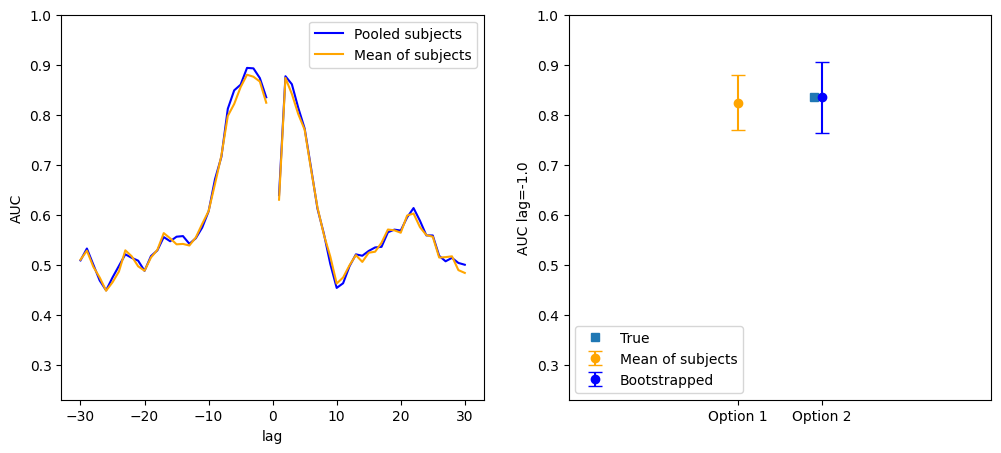

In [15]:
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(all_lags, auc_lags_all[:,0], color='blue', label="Pooled subjects")
ax[0].plot(all_lags, np.mean(auc_lags, axis=-1), color='orange', label="Mean of subjects")
ax[0].set_xlabel("lag")
ax[0].set_ylabel("AUC")
ax[0].legend()
ax[0].set_ylim([0.23,1])

ax[1].errorbar(1, auc_lags[example_lag_ID].mean(), fmt='o', capsize=5, color='orange', yerr=1.96*(np.std(auc_lags[example_lag_ID])/np.sqrt(N_subjects)), label="Mean of subjects")
ax[1].errorbar(2, auc_lags_all[example_lag_ID,1], fmt='o', capsize=5, color='blue', yerr=auc_lags_all_CI[example_lag_ID,1]-auc_lags_all_CI[example_lag_ID,0], label="Bootstrapped")
ax[1].plot(1.9, auc_lags_all[example_lag_ID,0], 's', label="True")
ax[1].set_ylim([0.23,1])
ax[1].set_xticks([1,2])
ax[1].set_xticklabels(["Option 1", "Option 2"])
ax[1].set_ylabel(f"AUC lag={all_lags[29]}")
ax[1].set_xlim([-1,4])
ax[1].legend()

A slightly more complete picture stems from ROC and DET analyses. We can proceed in two different ways:

1) computing the ROC curves for each subject individually and then interpolate and average the different curves or,
2) operating on the pooled dataset to obtain a finer resolution

Option 1 is not very recommended because interpolating ROCs is an unstable procedure and highly subjective. Furthemore, for the netsim dataset, were a few number of connections per subject exist (especially after applying k-neighbor constraints) the ROCs are quite sparse. We can show the ROC of an example subject though, because for larger networks this option might still be a valuable asset.

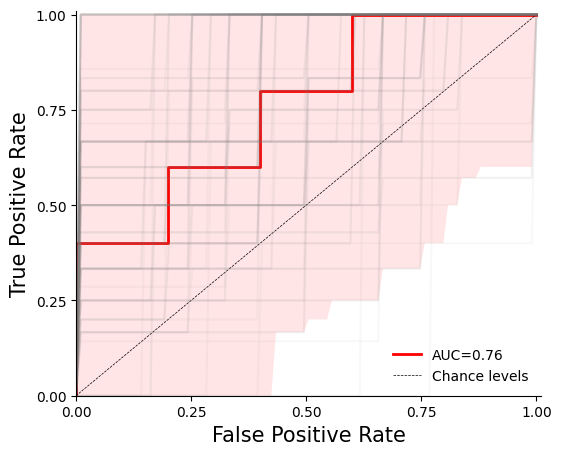

In [16]:
from analysis.stats import ROC_utils

# Option 1 for a single subject and lag
ROC = ROC_utils(predictions_w_k[example_lag][example_subject_ID], gts_k)
ROC_BOOTSTRAPPED = ROC.bootstrap_roc(resolution=0.01)
ROC.plot(sample_auc=auc_lags[example_lag_ID,example_subject_ID], color="red"); 

Option 2 give much more sensible results, because the number of samples (N_subjects*N_connections) is considerably larger. Thus, for small systems, pooling all the instances of the network into a single sample might proof insightfull.

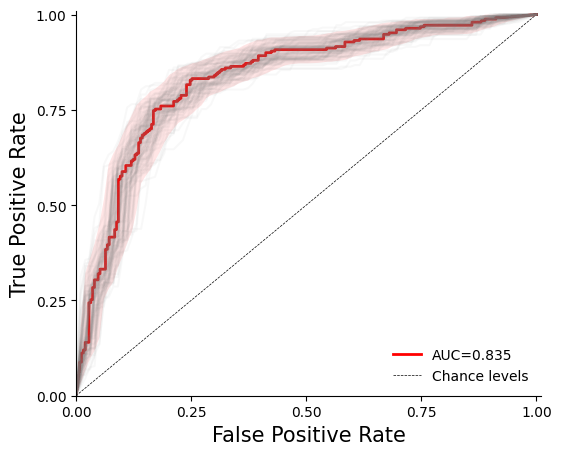

In [17]:
# Option 2 for the pooled sample
ROC = ROC_utils(predictions_w_k[example_lag].flatten(), all_gts_k)
ROC.bootstrap_roc(resolution=0.01)
ROC.plot(sample_auc=auc_lags_all[example_lag_ID,0], color="red"); 

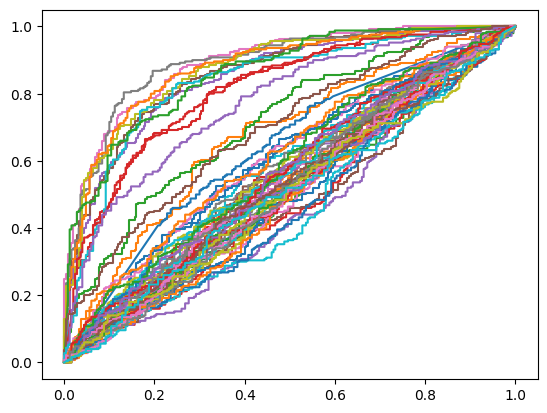

In [18]:
for i, lag in enumerate(all_lags):
    if lag != 0.0:
        ROC = ROC_utils(predictions_w_k[lag].flatten(), all_gts_k)
        plt.plot(ROC.fpr_real,ROC.tpr_real)

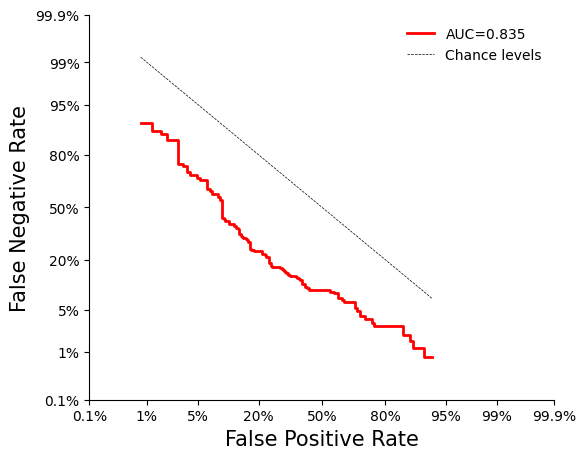

In [19]:
# For option 2 we can also study the DET curve
from analysis.stats import DET_utils
DET = DET_utils(predictions_w_k[example_lag].flatten(), all_gts_k)
DET.plot(sample_auc=auc_lags_all[example_lag_ID,0], color="red"); 